In [ ]:
# Estimating the Causal Impact of Higher Education on Income
#This project analyzes whether higher education truly increases income using both machine learning and causal inference techniques.
#The goal is to move beyond prediction and understand real-world cause-effect relationships.

In [ ]:
## Introduction
# Income inequality and the role of education is a key question in economics and policy.
# While machine learning models can identify patterns in data, they often fail to distinguish between correlation and causation.
# This project aims to estimate the causal impact of higher education on income.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Administrator\Downloads\archive (12)\adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
## Dataset Overview
#The dataset contains demographic and employment-related features.
#- Target Variable: Income (>50K or ≤50K)
#- Treatment Variable: Higher Education
#- Confounders: Age, gender, occupation, work hours
#These variables are used for both predictive and causal analysis.

In [ ]:
## Data Preprocessing
#Data cleaning steps include:
#- Handling missing values
#- Removing inconsistencies
#- Preparing variables for analysis
#This ensures reliable results in later stages.

In [3]:
df = df.replace("?", np.nan)
df = df.dropna()

In [4]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [5]:
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [6]:
confounders = ['age', 'hours.per.week', 'sex', 'occupation', 'workclass']

In [7]:
higher_edu = ['Bachelors', 'Masters', 'Doctorate', 'Prof-school']

df['treatment'] = df['education'].apply(lambda x: 1 if x in higher_edu else 0)

In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income', 'treatment'],
      dtype='object')

In [9]:
df[['education', 'treatment']].head()

,education,treatment
1,HS-grad,0
3,7th-8th,0
4,Some-college,0
5,HS-grad,0
6,10th,0


In [ ]:
## Exploratory Data Analysis
#Initial visualizations help understand relationships between variables such as education, gender, and income.
#However, these patterns only show correlation, not causation.

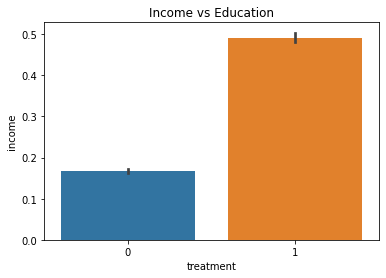

In [10]:
#EDA
sns.barplot(x='treatment', y='income', data=df)
plt.title("Income vs Education")
plt.show()

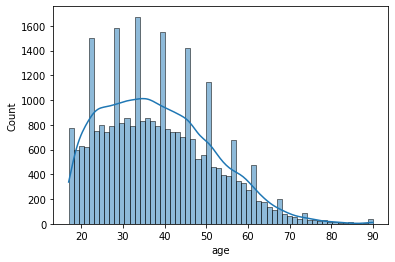

In [11]:
sns.histplot(df['age'], kde=True)
plt.show()

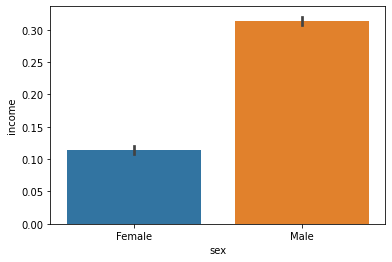

In [12]:
sns.barplot(x='sex', y='income', data=df)
plt.show()

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [14]:
df_encoded.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,treatment,workclass_Local-gov,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,82,132870,9,0,4356,18,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,54,140359,4,0,3900,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,41,264663,10,0,3900,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
5,34,216864,9,0,3770,45,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
6,38,150601,6,0,3770,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [15]:
X = df_encoded.drop(['income'], axis=1)
y = df_encoded['income']

In [ ]:
## Machine Learning Analysis
# A Random Forest model is used to predict income and identify important features.
# This step helps understand predictive relationships in the data.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
model.score(X_test, y_test)

0.8460135919111553

In [18]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

fnlwgt                               0.164960
age                                  0.153448
capital.gain                         0.094700
hours.per.week                       0.083602
marital.status_Married-civ-spouse    0.082369
education.num                        0.043880
treatment                            0.038114
marital.status_Never-married         0.034067
capital.loss                         0.029550
relationship_Not-in-family           0.020149
dtype: float64

In [ ]:
### Limitation of Machine Learning
#Although machine learning identifies important predictors, it does not establish causality.
#Education appears less important compared to other variables, but this may be due to confounding factors such as age and occupation.
#Therefore, causal methods are required.

In [ ]:
## Causal Inference Approach
#To estimate the true effect of education, Propensity Score Matching (PSM) is applied.
#This method helps compare similar individuals while controlling for confounders.

In [19]:
confounders = ['age', 'hours.per.week']

# categorical ko encode karna hoga
df_psm = pd.get_dummies(df[['treatment', 'income'] + confounders + ['sex', 'occupation', 'workclass']], drop_first=True)

In [ ]:
### Propensity Score Estimation
# A logistic regression model was used to estimate the probability of receiving higher education based on observed characteristics.

In [20]:
from sklearn.linear_model import LogisticRegression

X_psm = df_psm.drop(['treatment', 'income'], axis=1)
T = df_psm['treatment']

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_psm, T)

df_psm['propensity_score'] = ps_model.predict_proba(X_psm)[:,1]

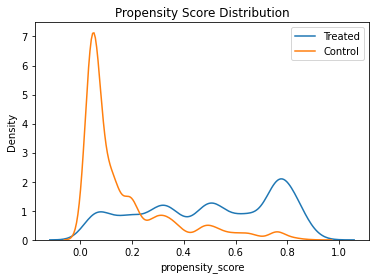

In [21]:
import seaborn as sns

sns.kdeplot(df_psm[df_psm['treatment']==1]['propensity_score'], label='Treated')
sns.kdeplot(df_psm[df_psm['treatment']==0]['propensity_score'], label='Control')
plt.legend()
plt.title("Propensity Score Distribution")
plt.show()

In [22]:
treated = df_psm[df_psm['treatment'] == 1]
control = df_psm[df_psm['treatment'] == 0]

# sort by score
treated = treated.sort_values(by='propensity_score')
control = control.sort_values(by='propensity_score')

# take equal size
min_len = min(len(treated), len(control))

treated = treated.iloc[:min_len]
control = control.iloc[:min_len]

In [ ]:
## Treatment Effect Estimation
#The Average Treatment Effect (ATE) measures the causal impact of higher education on income.
#It represents the difference in income between treated and matched control groups.

In [23]:
ate = treated['income'].mean() - control['income'].mean()
print("Estimated Treatment Effect (ATE):", ate)

Estimated Treatment Effect (ATE): 0.40643120716921455


In [ ]:
#The estimated treatment effect shows that higher education increases the probability of earning above 50K.
#This indicates a strong positive causal impact of education on income.

In [24]:
treated[['age', 'hours.per.week']].describe()
control[['age', 'hours.per.week']].describe()

,age,hours.per.week
count,7588.000000,7588.000000
mean,34.744992,36.555482
std,13.097286,10.108321
min,17.000000,1.000000
25%,24.000000,35.000000
50%,32.000000,40.000000
75%,43.000000,40.000000
max,90.000000,70.000000


In [ ]:
### Matching Process
#Nearest neighbor matching is used to pair individuals with similar propensity scores.
#This ensures that treated and control groups are comparable, reducing bias.

In [25]:
from sklearn.neighbors import NearestNeighbors

treated = df_psm[df_psm['treatment']==1]
control = df_psm[df_psm['treatment']==0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])

matched_control = control.iloc[indices.flatten()]

In [26]:
ate_improved = treated['income'].mean() - matched_control['income'].mean()
print(ate_improved)

0.1732999472851871


In [27]:
print("Treated age mean:", treated['age'].mean())
print("Control age mean:", matched_control['age'].mean())

Treated age mean: 40.55482340537691
Control age mean: 40.04652082235108


In [56]:
# Compare means of key confounders

cols = ['age', 'hours.per.week']

print("Treated Mean:\n", treated[cols].mean())
print("\nMatched Control Mean:\n", matched_control[cols].mean())

Treated Mean:
 age               40.554823
hours.per.week    43.825119
dtype: float64

Matched Control Mean:
 age               40.046521
hours.per.week    44.564180
dtype: float64


In [ ]:
## Balance Validation
#After matching, we check whether treated and control groups are similar.
#Standardized Mean Difference (SMD) is used to measure balance.
#SMD < 0.1 indicates good balance.

In [ ]:
#The results show that the treated and control groups are well balanced, indicating that matching was successful.

In [58]:
def smd(treated, control, col):
    return (treated[col].mean() - control[col].mean()) / \
           np.sqrt((treated[col].var() + control[col].var()) / 2)

for col in ['age', 'hours.per.week']:
    print(f"SMD for {col}: {smd(treated, matched_control, col)}")

SMD for age: 0.042624592888043725
SMD for hours.per.week: -0.06165534540863062


In [ ]:
## Heterogeneous Treatment Effects
#The impact of higher education may not be the same for all individuals.
#This section analyzes how the treatment effect varies across different groups such as age and gender.

In [60]:
df_psm['age_group'] = pd.cut(
    df_psm['age'],
    bins=[20,30,40,50,60,70],
    labels=['20-30','30-40','40-50','50-60','60+']
)

In [62]:
def calculate_ate(data):
    treated = data[data['treatment'] == 1]
    control = data[data['treatment'] == 0]
    
    return treated['income'].mean() - control['income'].mean()

In [64]:
for group in df_psm['age_group'].dropna().unique():
    subset = df_psm[df_psm['age_group'] == group]
    
    if len(subset) > 0:
        ate = calculate_ate(subset)
        print(f"ATE for age group {group}: {ate}")

ATE for age group 50-60: 0.36128768964855
ATE for age group 40-50: 0.35179463915590564
ATE for age group 30-40: 0.3351768543139131
ATE for age group 60+: 0.3884668508287293
ATE for age group 20-30: 0.12100092572459606


In [66]:
for gender in df_psm['sex_Male'].unique():
    subset = df_psm[df_psm['sex_Male'] == gender]
    
    ate = calculate_ate(subset)
    print(f"ATE for gender {gender}: {ate}")

ATE for gender 0: 0.19359932286725706
ATE for gender 1: 0.36799411248159175


In [ ]:
#The results show that the effect of higher education varies across different groups.
#This indicates that certain individuals benefit more from education than others, highlighting the presence of heterogeneous treatment effects.

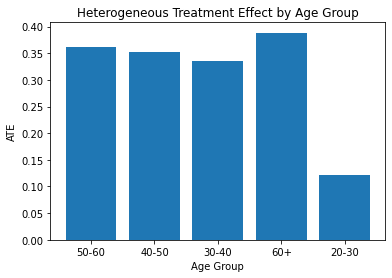

In [68]:
results = {}

for group in df_psm['age_group'].dropna().unique():
    subset = df_psm[df_psm['age_group'] == group]
    results[group] = calculate_ate(subset)

import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Heterogeneous Treatment Effect by Age Group")
plt.xlabel("Age Group")
plt.ylabel("ATE")
plt.show()

In [70]:
## Summary of Results

print("="*50)
print("PROJECT RESULTS SUMMARY")
print("="*50)
print(f"Random Forest Accuracy: {model.score(X_test, y_test):.2%}")
print(f"ATE (Simple): {ate:.4f}")
print(f"ATE (After PSM Matching): {ate_improved:.4f}")
print("="*50)
print("Conclusion: Higher education increases")
print(f"probability of earning >50K by {ate_improved:.1%}")

PROJECT RESULTS SUMMARY
Random Forest Accuracy: 84.60%
ATE (Simple): 0.3680
ATE (After PSM Matching): 0.1733
Conclusion: Higher education increases
probability of earning >50K by 17.3%


In [ ]:
## Conclusion

# Machine learning models alone were insufficient to capture the true impact of education.

# Causal analysis revealed that higher education has a significant positive effect on income.

# This highlights the importance of using causal inference for real-world decision-making.

In [ ]:
## Policy Implications

# The findings suggest that investment in education can improve income outcomes.

# However, since the effect varies across groups, targeted policies are needed to maximize benefits.